In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
df=pd.read_csv("ipldata.csv")
df.head()

C:\Users\jio86\AppData\Local\Temp\ipykernel_8928\1850997031.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("ipldata.csv")


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


In [60]:
# data analysis
df.shape

(289673, 30)

In [61]:
df.isnull().sum()

match_id                  0
date                      0
season                    0
event                     0
venue                     0
city                  12397
team1                     0
team2                     0
toss_winner               0
toss_decision             0
winner                    0
win_by_runs          156126
win_by_wickets       138527
player_of_match         828
innings                   0
batting_team              0
over                      0
ball                      0
batter                    0
bowler                    0
non_striker               0
runs_batter               0
runs_extras               0
runs_total                0
extras_wides              0
extras_noballs            0
extras_byes               0
extras_legbyes            0
wicket_kind          275267
wicket_player_out    275267
dtype: int64

In [62]:
df.columns

Index(['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out'],
      dtype='object')

In [63]:
# solution for the very first question starts from here
# Q1: Do teams that win the toss actually win more matches?
match_df = df.groupby('match_id').first().reset_index()

match_df.head()


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,335982,2008-04-18,2007/08,Indian Premier League,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,BB McCullum,0,1,1,0,0,0,1,caught,SC Ganguly
1,335983,2008-04-19,2007/08,Indian Premier League,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,ML Hayden,0,0,0,0,0,0,0,caught,PA Patel
2,335984,2008-04-19,2007/08,Indian Premier League,Feroz Shah Kotla,Delhi,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,YK Pathan,0,0,0,0,0,0,0,caught,T Kohli
3,335985,2008-04-20,2007/08,Indian Premier League,Wankhede Stadium,Mumbai,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,ST Jayasuriya,0,0,0,0,0,0,0,caught,L Ronchi
4,335986,2008-04-20,2007/08,Indian Premier League,Eden Gardens,Kolkata,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,Y Venugopal Rao,1,0,1,0,0,0,0,caught,Y Venugopal Rao


In [64]:
match_df.shape

(1218, 30)

In [65]:
print(match_df.columns)

Index(['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out'],
      dtype='object')


In [87]:
# Toss winner won match?
match_df['toss_win_match_win'] = match_df['toss_winner'] == match_df['winner']

# Count values
toss_result = match_df['toss_win_match_win'].value_counts()

print(toss_result)
toss_percentage = (toss_result / toss_result.sum()) * 100
print(toss_percentage)

toss_win_match_win
True     615
False    603
Name: count, dtype: int64
toss_win_match_win
True     50.492611
False    49.507389
Name: count, dtype: float64


In [67]:
# results for the first question
total_matches = toss_result.sum()

print("Total matches:", total_matches)
print("Matches where toss winner also won:", matches_won_after_toss)
print("Matches where toss winner lost:", matches_lost_after_toss)

Total matches: 1218
Matches where toss winner also won: 615
Matches where toss winner lost: 603


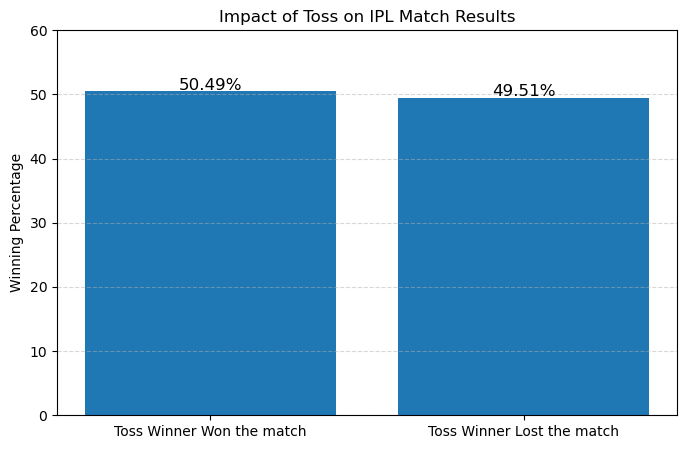

In [68]:
import matplotlib.pyplot as plt
# visualizations for the first solution
labels = ['Toss Winner Won the match', 'Toss Winner Lost the match']
values = toss_percentage.values

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f'{height:.2f}%',
        ha='center',
        fontsize=12
    )

plt.ylim(0, 60)

plt.ylabel("Winning Percentage")
plt.title("Impact of Toss on IPL Match Results")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [69]:
# solution for the very first question starts from here
# Q2: Which phase — powerplay, middle overs, or death overs — is most linked to winning?
def get_phase(over):
    
    if over <= 6:
        return 'Powerplay'
    
    elif over <= 15:
        return 'Middle Overs'
    
    else:
        return 'Death Overs'

df['phase'] = df['over'].apply(get_phase)

df[['over', 'phase']].head()

,over,phase
0,0,Powerplay
1,0,Powerplay
2,0,Powerplay
3,0,Powerplay
4,0,Powerplay


In [70]:
print(df.columns)

Index(['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out', 'phase'],
      dtype='object')


In [71]:
winner_info = match_df[['match_id', 'winner']]

df = df.merge(winner_info, on='match_id', how='left')

In [72]:
df['is_winner'] = df['batting_team'] == df['winner_y']
df[['batting_team', 'winner_y', 'is_winner']].head()

,batting_team,winner_y,is_winner
0,Sunrisers Hyderabad,Sunrisers Hyderabad,True
1,Sunrisers Hyderabad,Sunrisers Hyderabad,True
2,Sunrisers Hyderabad,Sunrisers Hyderabad,True
3,Sunrisers Hyderabad,Sunrisers Hyderabad,True
4,Sunrisers Hyderabad,Sunrisers Hyderabad,True


In [86]:
# results for the second question

phase_runs = (
    df.groupby(['phase', 'is_winner'])['runs_total']
    .mean()
    .reset_index()
)


phase_runs['is_winner'] = phase_runs['is_winner'].replace({
    True: 'Winning Teams',
    False: 'Losing Teams'
})


phase_runs.columns = [
    'Match Phase',
    'Team Type',
    'Average Runs Per Ball'
]

phase_runs['Average Runs Per Ball'] = phase_runs[
    'Average Runs Per Ball'
].round(3)

# Display final result
display(phase_runs)

,Match Phase,Team Type,Average Runs Per Ball
0,Death Overs,Losing Teams,1.481
1,Death Overs,Winning Teams,1.812
2,Middle Overs,Losing Teams,1.235
3,Middle Overs,Winning Teams,1.400
4,Powerplay,Losing Teams,1.193
5,Powerplay,Winning Teams,1.345


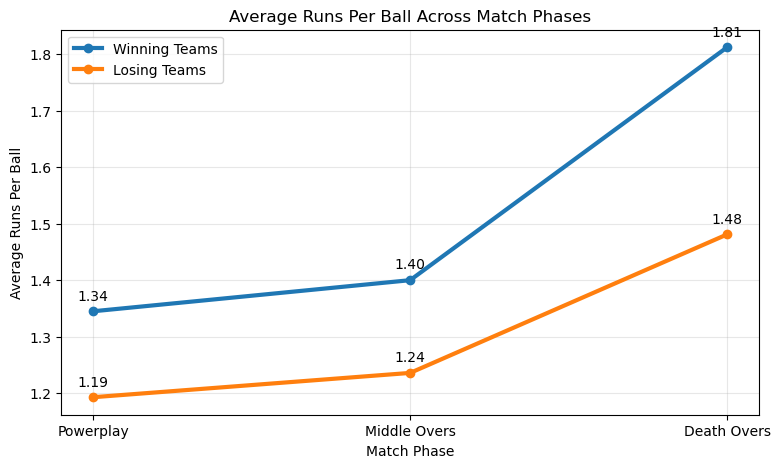

In [74]:
import matplotlib.pyplot as plt
# visualizations for the solution solution
phases = ['Powerplay', 'Middle Overs', 'Death Overs']

winner_runs = [1.345, 1.400, 1.812]
loser_runs = [1.193, 1.236, 1.481]

plt.figure(figsize=(9,5))

plt.plot(
    phases,
    winner_runs,
    marker='o',
    linewidth=3,
    label='Winning Teams'
)

plt.plot(
    phases,
    loser_runs,
    marker='o',
    linewidth=3,
    label='Losing Teams'
)

# Add value labels
for i, value in enumerate(winner_runs):
    plt.text(i, value + 0.02, f"{value:.2f}", ha='center')

for i, value in enumerate(loser_runs):
    plt.text(i, value + 0.02, f"{value:.2f}", ha='center')

plt.title("Average Runs Per Ball Across Match Phases")

plt.xlabel("Match Phase")
plt.ylabel("Average Runs Per Ball")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

In [79]:
# solution for the very first question starts from here
# Q2: Who are the top 5 batters and top 5 bowlers across 5 seasons?

print(df['season'].unique())
# Convert season column into clean string format
df['season'] = df['season'].astype(str).str[:4]

# Check unique seasons
print(df['season'].unique())

['2017' '2018' '2019' '2020' '2021' '2022' '2023' '2024' '2025' '2007'
 '2009' '2011' '2012' '2013' '2014' '2015' '2016' '2026']
['2017' '2018' '2019' '2020' '2021' '2022' '2023' '2024' '2025' '2007'
 '2009' '2011' '2012' '2013' '2014' '2015' '2016' '2026']


In [88]:
five_seasons = df[df['season'].between('2017', '2021')]

print("Filtered Dataset Shape:", five_seasons.shape)

Filtered Dataset Shape: (71444, 33)


In [89]:
top_batters = (
    five_seasons.groupby('batter')['runs_batter']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTop 5 Batters\n")
print(top_batters)


Top 5 Batters

batter
S Dhawan     2702
KL Rahul     2554
RR Pant      2313
V Kohli      2178
DA Warner    2078
Name: runs_batter, dtype: int64


In [90]:
wickets_df = five_seasons[
    five_seasons['wicket_kind'].notnull()
]

# Remove run outs (not credited to bowler)
wickets_df = wickets_df[
    wickets_df['wicket_kind'] != 'run out'
]
top_bowlers = (
    wickets_df.groupby('bowler')['wicket_kind']
    .count()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTop 5 Bowlers\n")
print(top_bowlers)


Top 5 Bowlers

bowler
JJ Bumrah      107
Rashid Khan     93
YS Chahal       83
K Rabada        79
SN Thakur       66
Name: wicket_kind, dtype: int64


In [92]:
top_batters_df = top_batters.reset_index()
top_batters_df.columns = ['Top Batters', 'Runs']


# Bowlers dataframe
top_bowlers_df = top_bowlers.reset_index()
top_bowlers_df.columns = ['Top Bowlers', 'Wickets']


# Combine both tables side-by-side
final_table = pd.concat(
    [top_batters_df, top_bowlers_df],
    axis=1
)

# Add ranking index
final_table.index = range(1, 6)
final_table.index.name = "Rank"

In [93]:
# visualizations for the third solution
styled_table = (
    final_table.style
    .set_caption("Top 5 IPL Batters and Bowlers (2017–2021)")
    
    # Header Styling
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#1f77b4'),
                ('color', 'white'),
                ('font-size', '14px'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'caption',
            'props': [
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('color', '#333')
            ]
        }
    ])
    
    # Cell Styling
    .set_properties(**{
        'text-align': 'center',
        'font-size': '13px',
        'border': '1px solid gray'
    })
    
    # Highlight maximum values
    .highlight_max(color='lightgreen', subset=['Runs', 'Wickets'])
)

# Display styled table
styled_table

,Top Batters,Runs,Top Bowlers,Wickets
Rank,,,,
1,S Dhawan,2702,JJ Bumrah,107
2,KL Rahul,2554,Rashid Khan,93
3,RR Pant,2313,YS Chahal,83
4,V Kohli,2178,K Rabada,79
5,DA Warner,2078,SN Thakur,66


In [ ]:
# One sentence — something the data showed you that genuinely surprised you

The most surprising insight was how little toss advantage mattered compared to the massive scoring gap during death overs.